# Control de servomotor DC en velocidad angular y ángulo

En esta práctica vamos a aplicar los conceptos teóricos aprendidos para controlar un servomotor tanto en velocidad ángular como en ángulo. Usaremos los conceptos de identificaciónb de modelos, control PI, control PID, región de diseño y límites de frecuencia para diseñar un sistema de control realimentado.


## Carga del paquete DCMotor y definición del sistema

Asi cargamos el paquete de DCMotor y definimos la planta con la cual estamos trabajando. Si sale algun error corra la celda nuevamente.

In [2]:
# cargar el paquete
using DCMotor

# definicion del sistema
motor = MotorSystem();

## Identificación del sistema - Modelo estático

Ahora obtendremos un modelo estático del sistema, aplicando diferentes voltajes y midiendo la velocidad de estado estacionario. Esto se hace mediante la siguiente función

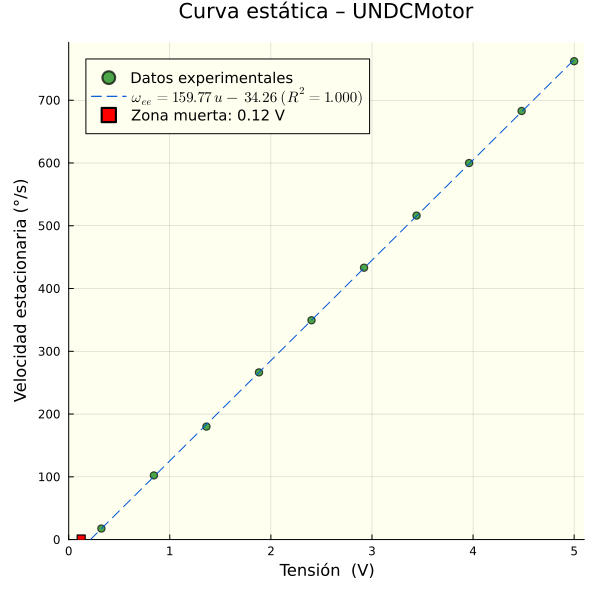

Referencia fijada a 0.00 

Modelo estático completo


In [3]:
get_static_model(motor);

### Preguntas orientadoras sobre el modelo estático

Discuta inmediatamente estas preguntas con su compañero e incluya una respuesta breve en este reporte.

+  ¿Cómo puede la zona muerta afectar el control en bajas velocidades?
+  ¿Hasta que velocidad máxima se puede controlar el motor?

## Identificación del sistema - Modelo dinámico

A continuación vamos a obtener un modelo dinámico del motor usando como entrada una onda binaria pseudoaleatoria
en el punto de operación en que la velocidad angular es $400^o/s$. Recordemos que la función de transferencia simplificada tiene la forma:

$$G(s)=\frac{\Omega(s)}{U(s)}=\frac{b}{s+a}$$

In [ ]:
G, L = get_model_prbs(motor, yop=400);

## Control de velocidad del servomotor con un controlador PI - Sintonía algebraica

A partir del modelo obtenido vamos a realizar un control PI de dos grados de libertad de acuerdo con la teoria vista. Tenemos las siguientes especificaciones para ese sistema de control:


| Controlador | $t_{ee}$ (tiempo de establecimiento) | $t_r$ (tiempo de subida) | $SP$ (sobrepico) |
|-------------|-----------|-------|------|
| PI-VEL-1        | $\leq\, 1.0 s$     | $\leq\, 0.25 s$ | $\approx 10\%$  |

Además sabemos que el retardo del sistema de control en lazo cerrado es $0.02\,s$, debido al muestreo digital.

1. Calcule el valor de $\zeta$ necesario para lograr el sobrepico deseado.
2. Encuentre el rango de valores de $\omega_n$ (inferior y superior) que puede colocarse para constantes no negativas, cumplir  las especificaciones y el retardo inherente al muestreo digital ($\omega_n\leq 0.5/L$, siendo $L$ el retardo).

3. Realice iteraciones experimentales progresivas con el fin de ajustar el valor de $\omega_n$ hacia el valor mayor posible, manteniendo las especificaciones. Es posible que tenga que ajustar experimentalmente $\zeta$ después del ajuste de $\omega_n$. 

4. Observe que el controlador efectivamente ajusta la velocidad de la rueda (en  $^o/s$), según la referencia fijada en la perilla.


5. Use un valor de $\omega_n$ por debajo de los limites teóricos (por ejemplo $\omega_n=2$) y un valor de $\omega_n$ muy por encima del valor máximo teórico. Tenga cuidado de ajustar el valor de $t_1$ en la función ``step_closed`` [(vea la ayuda)](https://nebisman.github.io/DCMotor.jl/dev/funciones/control/step_closed/) para que la velocidad llegue al estado estacionario.  Discuta con su compañero lo que pasa en ambos casos e incluya sus reflexiones sobre los comportamientos observados. 






In [ ]:
a = 
b = 
ωn =
ζ = 

kp =
ki =

# calculo de las constantes, incluya aqui el calculo de las constantes del PID, kp, ki 
# con base en los valores de ωn y ζ, y los valores de a y b

# función de lazo cerrado teorica
T = ωn^2/(s^2 + 2*ζ*ωn*s + ωn^2)

# aqui programo el PID
set_pid(motor,  kp=kp, ki=ki, kd=0,  output=:speed)

# aqui ejecuto el experimento de escalón de velocidad con un escalón de 0 a 360 grados.
resultado = step_closed(motor, r0 = 0, r1 = 400,  t0 = 0.5, t1 =2); 

# aqui visualizo las metricas y comparo con el desempeño deseado de la función de lazo cerrado T
stepinfo(resultado, T, risetime_th = (0.0, 0.9))

## Control de ángulo de un servomotor con un controlador PID - sintonía algebraica

Ahora vamos a hacer control del ángulo del servomotor usando un PID. Si al modelo que ya obtivimos le agregamos un integrador, obtenemos la función de transferencia en ángulo, 
dada por:

$$G_{ang}(s)=\dfrac{\theta(s)}{U(s)}=\dfrac{b}{s(s+a)}$$
Vamos a simular en lazo abierto este sistema a un escalón de $2.5\,V$

In [ ]:
G_ang = tf(motor, output=:angle)
plot(step(2.5 * G_ang, 10), xlabel="Tiempo [s]", ylabel="Angulo en grados")

### Pregunta orientadora

Viendo la simulación: 
+  ¿Si tomamos como salida el ángulo, el servomotor es estable o inestable en lazo abierto? Justifique.

## Diseño de un controlador PID

A partir del modelo obtenido,  vamos a diseñar un control PID de dos grados de libertad de acuerdo con la actividad en clase. Tenemos las siguientes especificaciones: 


| Controlador | $t_{ee}$ (tiempo de establecimiento) | $t_r$ (tiempo de subida) | $SP$ (sobrepico) |
|-------------|-----------|-------|------|
| PID-ANGULO-1        | $\leq\,8 s$     | $\leq\,0.3 s$ | $\leq 5\%$  |


Adicionalmente, la restricción de energía impone que:

$$|u(t)|\leq 5\,V$$

La referencia de ángulo a lo sumo va a cambiar en $100$ grados.


1. Encuentre la región de diseño que satisface las especificaciones.

2. Encuentre el rango de valores de $\omega_n$ (inferior y superior) que puede colocarse de acuerdo con las especificaciones y el retardo

3. Use las fórmulas para $k_p$, $k_i$ y $k_d$ que dedujo en la actividad 1, junto con el modelo $G_{ang}$. Puede usar para  $m$ un valor entre 2 y 3. 

4. Realice iteraciones experimentales progresivas ajustando los polos de lazo cerrado, de manera que se satisfagan las especificaciones y no se sature la señal de control cuando se aplica un paso de $0$ a $100^o$ con la función ``step_closed``.
5. Dibuje la ubicación final de los polos de lazo cerrado y la región de diseño. Dibuje el sistema implementado incluyendo los valores de cada constante del controlador y la planta.

In [ ]:
## Calculo de las constantes del PID para el sistema de segundo orden


ωn = 
ζ = 
m = 

# funcion de lazo cerrado teorica para el control de ángulo
Tang  = m*ωn^3/((s+m*ωn)*(s^2 + 2*ζ*ωn*s +ωn^2))

# complete las lineas de codigo para calcular las constantes del PID

kp = 
ki = 
kd = 

set_pid(motor,  kp=kp, ki=ki, kd=kd,  output=:angle)

# complete las lineas de código para ejecutar el experimento de escalón de ángulo con un escalón de 0 a 400 grados
# y visualizar las métricas y compararlas con el desempeño deseado de la función de lazo cerrado Tang con stepinfo



### Reflexiones

Incluya sus reflexiones sobre esta práctica.